In [1]:
# ResNet CNN for ERA5 Wave Spectra with Residual Learning (No Physics Constraints)
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

print("Libraries imported successfully")

Libraries imported successfully


In [12]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) - INCLUDED
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) - INCLUDED
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")   # NEW
print(f"b2: {b2.shape}")   # NEW

# Check for any NaN values in loaded data
print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")  # NEW
print(f"NaN values in b2: {np.isnan(b2).sum()}")  # NEW

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in S2D: 0
NaN values in a1: 0
NaN values in b1: 0
NaN values in a2: 0
NaN values in b2: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19140\615587787.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [2]:
# Compute baseline reconstruction using directional moments (first harmonic only)
print("Computing baseline spectrum reconstruction...")

def compute_baseline_spectrum(S1D, a1, b1, n_dir=24):
    """Reconstruct 2D spectrum from 1D spectrum and directional moments"""
    # Use exact same directional grid as in preprocessing
    direction_deg = 7.5 + 15 * np.arange(n_dir)  # ERA5 directions: 7.5°, 22.5°, ..., 352.5°
    theta = np.deg2rad(direction_deg)
    ddir = np.deg2rad(15.0)  # 15° spacing
    
    # Initialize output
    S_baseline = np.zeros((S1D.shape[0], S1D.shape[1], n_dir))
    
    for i in range(S1D.shape[0]):
        for j in range(S1D.shape[1]):
            if S1D[i, j] > 1e-15:  # Only process non-zero frequencies
                # Correct first-harmonic directional distribution formula
                D = (1/(2*np.pi)) * (1 + 2*a1[i, j] * np.cos(theta) + 2*b1[i, j] * np.sin(theta))
                
                # Ensure non-negative
                D = np.maximum(D, 0)
                
                # Normalize using discrete integration
                integral = np.sum(D) * ddir
                if integral > 1e-10:
                    D = D / integral
                else:
                    D = np.ones(n_dir) / n_dir  # Uniform if coefficients invalid
                
                # Multiply by 1D spectrum
                S_baseline[i, j, :] = S1D[i, j] * D
    
    return S_baseline



Computing baseline spectrum reconstruction...


In [14]:
# Compute baseline reconstruction
S_baseline = compute_baseline_spectrum(S1D, a1, b1)

# Compute residuals (what the ResNet CNN will learn)
residuals = S2D - S_baseline

print(f"Baseline shape: {S_baseline.shape}")
print(f"Residuals shape: {residuals.shape}")
print(f"Baseline energy: {np.mean(np.sum(S_baseline, axis=(1,2))):.4f}")
print(f"Original energy: {np.mean(np.sum(S2D, axis=(1,2))):.4f}")
print(f"Residual energy: {np.mean(np.sum(residuals, axis=(1,2))):.4f}")

# Check for NaN in computed arrays
print(f"NaN in baseline: {np.isnan(S_baseline).sum()}")
print(f"NaN in residuals: {np.isnan(residuals).sum()}")

Baseline shape: (9504, 30, 24)
Residuals shape: (9504, 30, 24)
Baseline energy: 18.5994
Original energy: 18.5994
Residual energy: 0.0000
NaN in baseline: 0
NaN in residuals: 0


In [15]:
# Prepare inputs for CNN ResNet model (ALL moments)
print("Preparing inputs for CNN ResNet model...")

# Create model inputs by concatenating ALL features
# Input features: S1D (30) + a1 (30) + b1 (30) + a2 (30) + b2 (30) = 150 features
batch_size, n_freq, n_dir = S2D.shape
n_features = n_freq * 5  # ALL 5 components

# Flatten and concatenate ALL inputs
inputs = np.concatenate([
    S1D.reshape(batch_size, -1),  # Shape: (batch_size, 30)  
    a1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    b1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    a2.reshape(batch_size, -1),   # Shape: (batch_size, 30) - NEW
    b2.reshape(batch_size, -1)    # Shape: (batch_size, 30) - NEW
], axis=1)  # Final shape: (batch_size, 150)

# Target is the residual (flattened for MSE)
targets = residuals.reshape(batch_size, -1)  # Shape: (batch_size, 30*24=720)
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")
print(f"Input features: {n_features} (S1D + a1 + b1 + a2 + b2)")
print(f"Input channels: S1D, a1, b1, a2, b2")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=(1,2))
    target_mask = ~np.isnan(targets).any(axis=(1,2))
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S2D = S2D[valid_mask]
    S_baseline = S_baseline[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")
print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for CNN ResNet model...
Input shape: (9504, 150)
Target shape: (9504, 720)
Input features: 150 (S1D + a1 + b1 + a2 + b2)
Input channels: S1D, a1, b1, a2, b2
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [-4.785140, 14.124423]
Input mean: -0.121308, std: 0.506509
Target mean: 0.000000, std: 0.117018


In [16]:
# Normalize inputs and split data
print("Normalizing inputs and splitting data...")

# Normalize inputs to improve training stability
input_mean = inputs.mean(axis=0, keepdims=True)
input_std = inputs.std(axis=0, keepdims=True) + 1e-8  # Add small epsilon for numerical stability
inputs_norm = (inputs - input_mean) / input_std


# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/resnet2_res_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/resnet2_res_normalization.npz")

# For targets, use raw residuals without scaling
targets_norm = targets
target_scale = 1.0  # No scaling applied

print(f"Input normalization - Mean: {input_mean.mean():.6f}, Std: {input_std.mean():.6f}")
print(f"Target scaling factor: {target_scale:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Also split original data for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]
S_baseline_train = S_baseline[train_idx]
S_baseline_val = S_baseline[val_idx]
S_baseline_test = S_baseline[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/resnet2_res_normalization.npz
Input normalization - Mean: -0.121308, Std: 0.339513
Target scaling factor: 1.000000
Normalized input range: [-8.264766, 23.587287]
Normalized target range: [-4.785140, 14.124423]
Data splits:
Train: 6652 samples
Val: 1425 samples
Test: 1427 samples
Using device: cpu


In [3]:
# Define CNN Residual Block
class CNNResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout_rate=0.1):
        super(CNNResidualBlock, self).__init__()
        
        padding = kernel_size // 2  # Same padding
        
        self.conv1 = nn.Conv2d(channels, channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(channels, channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(channels)
        
        self.dropout = nn.Dropout2d(dropout_rate)
        self.final_relu = nn.ReLU()
    
    def forward(self, x):
        # Save input for skip connection
        identity = x
        
        # First convolution
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout(out)
        
        # Second convolution
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Add skip connection
        out += identity
        
        # Final activation
        out = self.final_relu(out)
        
        return out

# Define CNN ResNet for Residual Learning
class CNNResNet(nn.Module):
    def __init__(self, input_size, hidden_channels=64, num_blocks=3, dropout_rate=0.1):
        super(CNNResNet, self).__init__()
        
        self.input_size = input_size
        self.hidden_channels = hidden_channels
        self.num_blocks = num_blocks
        
        # Project 1D features to 2D feature map
        # 150 → (64 × 30 × 24)
        self.projection = nn.Linear(input_size, hidden_channels * 30 * 24)
        
        # CNN residual blocks
        self.res_blocks = nn.ModuleList([
            CNNResidualBlock(hidden_channels, kernel_size=3, dropout_rate=dropout_rate) 
            for _ in range(num_blocks)
        ])
        
        # Final convolution to single channel
        self.final_conv = nn.Conv2d(hidden_channels, 1, kernel_size=3, padding=1)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # He initialization for ReLU
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                # He initialization for linear layers
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        # Project to 2D feature map
        x = self.projection(x)  # (batch, 64*30*24)
        x = x.reshape(batch_size, self.hidden_channels, 30, 24)  # (batch, 64, 30, 24)
        
        # Apply residual blocks
        for block in self.res_blocks:
            x = block(x)
        
        # Final convolution to single channel
        x = self.final_conv(x)  # (batch, 1, 30, 24)
        x = x.squeeze(1)  # (batch, 30, 24)
        
        # Flatten for MSE loss compatibility
        x = x.reshape(batch_size, -1)  # (batch, 720)
        
        return x



In [18]:
# Create model
input_size = X_train.shape[1]   # 150 features (S1D + a1 + b1 + a2 + b2)
hidden_channels = 64            # CNN hidden channels
num_blocks = 3                  # Number of CNN residual blocks

model = CNNResNet(input_size, hidden_channels, num_blocks).to(device)

print(f"CNN ResNet model created:")
print(f"Input size: {input_size} (S1D + a1 + b1 + a2 + b2)")
print(f"Hidden channels: {hidden_channels}")
print(f"Output size: 720 (30 freq × 24 dir) - residuals")
print(f"CNN residual blocks: {num_blocks}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
test_batch = X_train_t[:4]  
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("CNN ResNet architecture defined successfully")

CNN ResNet model created:
Input size: 150 (S1D + a1 + b1 + a2 + b2)
Hidden channels: 64
Output size: 720 (30 freq × 24 dir) - residuals
CNN residual blocks: 3
Number of parameters: 7,180,993
Test output shape: torch.Size([4, 720])
Test output range: [-38.045727, 51.819004]
Test output has NaN: False
CNN ResNet architecture defined successfully


In [4]:
# Define reconstruction and loss functions
def reconstruct_2d_spectrum(residuals, baseline_tensor, batch_size):
    """Reconstruct 2D spectrum from predicted residuals and baseline"""
    
    # Reshape residuals from flattened (batch, 720) to 2D (batch, 30, 24)
    if len(residuals.shape) == 2 and residuals.shape[1] == 720:
        residuals = residuals.reshape(batch_size, 30, 24)
    
    # Flatten baseline if needed to match flattened residuals
    if len(baseline_tensor.shape) == 3:
        baseline_flat = baseline_tensor.reshape(batch_size, -1)
        residuals_flat = residuals.reshape(batch_size, -1)
        
        # Add residuals to baseline in flattened form
        reconstructed_flat = baseline_flat + residuals_flat
        
        # Reshape back to 2D
        reconstructed = reconstructed_flat.reshape(batch_size, 30, 24)
    else:
        # Both are already in same shape
        reconstructed = baseline_tensor + residuals
    
    # Enforce non-negativity
    reconstructed = torch.clamp(reconstructed, min=0.0)
    
    return reconstructed

In [20]:
# Test reconstruction function
print("Testing reconstruction function...")
with torch.no_grad():
    # Create test tensors
    test_residuals = model(X_train_t[:4])
    test_baseline = torch.FloatTensor(S_baseline_train[:4]).to(device)
    test_target = torch.FloatTensor(S2D_train[:4]).to(device)
    
    # Reconstruct spectrum
    test_recon = reconstruct_2d_spectrum(test_residuals, test_baseline, 4)
    
    # Compute MSE loss
    mse_loss = torch.mean((test_recon - test_target)**2)
    
    print(f"Test reconstruction shape: {test_recon.shape}")
    print(f"Test MSE loss: {mse_loss.item():.6f}")
    print(f"Reconstruction range: [{test_recon.min().item():.6f}, {test_recon.max().item():.6f}]")
    
    # Check for NaN in loss
    if torch.isnan(mse_loss):
        print("WARNING: NaN in loss function!")
    else:
        print("✓ Reconstruction function working correctly")

print("Functions defined successfully")

Testing reconstruction function...
Test reconstruction shape: torch.Size([4, 30, 24])
Test MSE loss: 145.705658
Reconstruction range: [0.000000, 50.504627]
✓ Reconstruction function working correctly
Functions defined successfully


In [21]:
# Training setup
print("Setting up training...")

# Prepare baseline arrays as tensors for training
S_baseline_train_t = torch.FloatTensor(S_baseline_train).to(device)
S_baseline_val_t = torch.FloatTensor(S_baseline_val).to(device)
S2D_train_t = torch.FloatTensor(S2D_train).to(device)
S2D_val_t = torch.FloatTensor(S2D_val).to(device)

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate for ResNet
batch_size = 32         # Batch size
num_epochs = 50         # Number of epochs
weight_decay = 1e-5     # L2 regularization

# Create data loaders
train_dataset = TensorDataset(X_train_t, y_train_t, S_baseline_train_t, S2D_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t, S_baseline_val_t, S2D_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

# MSE loss function (no physics constraints)
criterion = nn.MSELoss()

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Loss function: MSE only (no physics constraints)")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Ready to start ResNet CNN training")

Setting up training...
Training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Train batches: 208
  Val batches: 45
  Loss function: MSE only (no physics constraints)
Ready to start ResNet CNN training


In [22]:
# Training loop
model_path = "models/resnet2_res.pth"

print("Starting ResNet CNN training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass - predict residuals
        residuals_pred = model(batch_x)
        
        # Reconstruct 2D spectrum
        reconstructed = reconstruct_2d_spectrum(
            residuals_pred, batch_baseline, batch_x.shape[0]
        )
        
        # Compute MSE loss on reconstructed spectrum
        loss = criterion(reconstructed, batch_target_2d)
        
        # Check for NaN 
        if torch.isnan(loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Residuals range: [{residuals_pred.min().item():.6f}, {residuals_pred.max().item():.6f}]")
            print(f"  Reconstructed range: [{reconstructed.min().item():.6f}, {reconstructed.max().item():.6f}]")
            break
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y, batch_baseline, batch_target_2d) in enumerate(val_loader):
            # Forward pass
            residuals_pred = model(batch_x)
            
            # Reconstruct 2D spectrum
            reconstructed = reconstruct_2d_spectrum(
                residuals_pred, batch_baseline, batch_x.shape[0]
            )
            
            # Compute MSE loss
            loss = criterion(reconstructed, batch_target_2d)
            
            if not torch.isnan(loss):
                epoch_val_loss += loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ New best ResNet residual model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 50)

print("ResNet CNN training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting ResNet CNN training...
  Batch 50/208, Loss: 2.097555
  Batch 100/208, Loss: 0.079682
  Batch 150/208, Loss: 0.011953
  Batch 200/208, Loss: 0.006096
Epoch 1/50
  Train Loss: 9.939129
  Val Loss: 0.024918
  Learning Rate: 1.00e-04
  ✓ New best ResNet residual model saved (val_loss: 0.024918)
--------------------------------------------------
  Batch 50/208, Loss: 0.016863
  Batch 100/208, Loss: 0.005611
  Batch 150/208, Loss: 0.014465
  Batch 200/208, Loss: 0.019115
Epoch 2/50
  Train Loss: 0.030047
  Val Loss: 0.024899
  Learning Rate: 1.00e-04
  ✓ New best ResNet residual model saved (val_loss: 0.024899)
--------------------------------------------------
  Batch 50/208, Loss: 0.015413
  Batch 100/208, Loss: 0.028320
  Batch 150/208, Loss: 0.027079
  Batch 200/208, Loss: 0.204233
Epoch 3/50
  Train Loss: 0.029984
  Val Loss: 0.024899
  Learning Rate: 1.00e-04
--------------------------------------------------
  Batch 50/208, Loss: 0.014801
  Batch 100/208, Loss: 0.004213
  Ba

In [23]:
# Model evaluation and R-squared analysis
print("Evaluating ResNet CNN model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Prepare test data
S_baseline_test_t = torch.FloatTensor(S_baseline_test).to(device)
S2D_test_t = torch.FloatTensor(S2D_test).to(device)

# Make predictions on test set
with torch.no_grad():
    test_residuals = model(X_test_t)
    test_reconstructed = reconstruct_2d_spectrum(
        test_residuals, S_baseline_test_t, len(X_test_t)
    )

# Convert back to numpy for evaluation
test_reconstructed_np = test_reconstructed.cpu().numpy()
test_target_np = S2D_test

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# Baseline error vs ResNet CNN error
baseline_error = compute_relative_error(S_baseline_test, S2D_test)
resnet_error = compute_relative_error(test_reconstructed_np, test_target_np)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

# L2 errors for baseline
norm_true = np.linalg.norm(test_target_np.reshape(n_time, -1), axis=1)
norm_diff_baseline = np.linalg.norm((S_baseline_test - test_target_np).reshape(n_time, -1), axis=1)
relative_l2_error_baseline = norm_diff_baseline / (norm_true + epsilon_l2)
l2_baseline_error = np.mean(relative_l2_error_baseline)

# L2 errors for ResNet CNN
norm_diff_resnet = np.linalg.norm((test_reconstructed_np - test_target_np).reshape(n_time, -1), axis=1)
relative_l2_error_resnet = norm_diff_resnet / (norm_true + epsilon_l2)
l2_resnet_error = np.mean(relative_l2_error_resnet)

# R-squared calculation
print("Computing R-squared values...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_baseline_flat = S_baseline_test.flatten()
y_pred_resnet_flat = test_reconstructed_np.flatten()

# Calculate R-squared for baseline model
ss_res_baseline = np.sum((y_true_flat - y_pred_baseline_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_baseline = 1 - (ss_res_baseline / ss_tot)

# Calculate R-squared for ResNet CNN model
ss_res_resnet = np.sum((y_true_flat - y_pred_resnet_flat) ** 2)
r2_resnet = 1 - (ss_res_resnet / ss_tot)

print("\n" + "="*60)
print("RESNET CNN WITH RESIDUAL LEARNING EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"Baseline error (moments only):     {baseline_error:.6f}")
print(f"ResNet CNN error (with residuals): {resnet_error:.6f}")
print(f"Improvement factor:                {baseline_error/resnet_error:.4f}x")
print(f"Relative improvement:              {(baseline_error-resnet_error)/baseline_error*100:.2f}%")

print("\nL2 ERROR (RELATIVE) ANALYSIS:")
print(f"Baseline L2 error:     {l2_baseline_error:.6f}")
print(f"ResNet CNN L2 error:   {l2_resnet_error:.6f}")
print(f"L2 Improvement:        {l2_baseline_error - l2_resnet_error:.6f}")
print(f"L2 Reduction (%):      {(l2_baseline_error - l2_resnet_error)/l2_baseline_error*100:.2f}%")

print("\nR-SQUARED ANALYSIS:")
print(f"Baseline R²:           {r2_baseline:.6f}")
print(f"ResNet CNN R²:         {r2_resnet:.6f}")
print(f"R² Improvement:        {r2_resnet - r2_baseline:.6f}")
print(f"R² Improvement (%):    {(r2_resnet - r2_baseline)/abs(r2_baseline)*100:.2f}%")

# Correlation coefficients  
corr_baseline = np.corrcoef(y_true_flat, y_pred_baseline_flat)[0, 1]
corr_resnet = np.corrcoef(y_true_flat, y_pred_resnet_flat)[0, 1]

print(f"\nPearson correlations:")
print(f"  Baseline: {corr_baseline:.6f}")
print(f"  ResNet CNN: {corr_resnet:.6f}")

# Energy conservation check
energy_conservation = np.abs(
    np.mean(np.sum(test_reconstructed_np, axis=(1,2))) - np.mean(np.sum(test_target_np, axis=(1,2)))
) / np.mean(np.sum(test_target_np, axis=(1,2)))

print(f"\nAdditional statistics:")
print(f"Test set size:                     {len(test_target_np)} samples")
print(f"Mean target energy:                {np.mean(np.sum(test_target_np, axis=(1,2))):.6f}")
print(f"Mean ResNet energy:                {np.mean(np.sum(test_reconstructed_np, axis=(1,2))):.6f}")
print(f"Mean baseline energy:              {np.mean(np.sum(S_baseline_test, axis=(1,2))):.6f}")
print(f"Energy conservation error:         {energy_conservation:.6f}")

print(f"\nRESNET CNN MODEL SUMMARY:")
print(f"  Input: 5 channels (S1D + a1 + b1 + a2 + b2) → (batch, 5, 30)")
print(f"  Architecture: ResNet CNN with residual blocks")
print(f"  Learning: Residual corrections to baseline spectrum")
print(f"  Loss: MSE only (no physics constraints)")
print(f"  Final Performance:")
print(f"    - Weighted Error: {resnet_error:.6f}")
print(f"    - L2 Error (Relative): {l2_resnet_error:.6f}")
print(f"    - R²: {r2_resnet:.6f} ({r2_resnet*100:.2f}% variance explained)")
print(f"    - Improvement over baseline: {baseline_error/resnet_error:.2f}x")

print("\n✓ ResNet CNN with residual learning evaluation completed!")
print("="*60)

Evaluating ResNet CNN model...
Computing R-squared values...

RESNET CNN WITH RESIDUAL LEARNING EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
Baseline error (moments only):     0.667998
ResNet CNN error (with residuals): 1.000000
Improvement factor:                0.6680x
Relative improvement:              -49.70%

L2 ERROR (RELATIVE) ANALYSIS:
Baseline L2 error:     0.651692
ResNet CNN L2 error:   1.000000
L2 Improvement:        -0.348308
L2 Reduction (%):      -53.45%

R-SQUARED ANALYSIS:
Baseline R²:           0.524034
ResNet CNN R²:         -0.036413
R² Improvement:        -0.560447
R² Improvement (%):    -106.95%

Pearson correlations:
  Baseline: 0.739306
  ResNet CNN: nan

Additional statistics:
Test set size:                     1427 samples
Mean target energy:                27.796831
Mean ResNet energy:                0.000000
Mean baseline energy:              27.796832
Energy conservation error:         1.000000

RESNET CNN MODEL SUMMARY:
  Input: 5 channels (S1D + a1 + b

d:\projects\ocnwvs\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\projects\ocnwvs\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


# 🌊 Evaluation on Independent Dataset

Evaluate the trained ResNet CNN with residual learning on completely separate evaluation data.

In [5]:
# Load ERA5 evaluation data and normalization parameters
print("Loading ERA5 evaluation data for final assessment...")
model_path = "models/resnet2_res.pth"
eval_data_path = "eval_data\\processed_0\\era5_wave_eval.npz"
eval_data = np.load(eval_data_path)

print(f"ERA5 evaluation data loaded:")
print(f"  X shape: {eval_data['X'].shape}")
print(f"  y shape: {eval_data['y'].shape}")

# Load normalization parameters
norm_params = np.load("models/resnet2_res_normalization.npz")
eval_input_mean = norm_params['input_mean']
eval_input_std = norm_params['input_std']

print("Normalization parameters loaded for consistent preprocessing")

# Extract evaluation set components
eval_X = eval_data['X']  # Shape: (samples, 5, 30) - S1D, a1, b1, a2, b2
eval_y = eval_data['y']  # Shape: (samples, 30, 24) - 2D spectra

print(f"ERA5 evaluation set: {eval_X.shape[0]} samples")
print(f"Input channels: S1D, a1, b1, a2, b2")

Loading ERA5 evaluation data for final assessment...
ERA5 evaluation data loaded:
  X shape: (1416, 5, 30)
  y shape: (1416, 30, 24)
Normalization parameters loaded for consistent preprocessing
ERA5 evaluation set: 1416 samples
Input channels: S1D, a1, b1, a2, b2


In [6]:
# Preprocess ERA5 evaluation data using existing functions  
print("Preprocessing ERA5 evaluation data...")

# Extract components from evaluation data
eval_S1D = eval_X[:, 0, :]  # 1D spectra: (samples, 30)
eval_a1 = eval_X[:, 1, :]   # Directional moment a1: (samples, 30)
eval_b1 = eval_X[:, 2, :]   # Directional moment b1: (samples, 30)
eval_a2 = eval_X[:, 3, :]   # Directional moment a2: (samples, 30)
eval_b2 = eval_X[:, 4, :]   # Directional moment b2: (samples, 30)

# Compute baseline reconstruction using existing function
eval_baseline = compute_baseline_spectrum(eval_S1D, eval_a1, eval_b1)

print(f"ERA5 evaluation baseline computed:")
print(f"  Baseline shape: {eval_baseline.shape}")
print(f"  Baseline range: [{eval_baseline.min():.6f}, {eval_baseline.max():.6f}]")

# Flatten evaluation inputs to match training format (150 features)
eval_batch_size = eval_X.shape[0]
eval_inputs_flat = np.concatenate([
    eval_S1D.reshape(eval_batch_size, -1),  # Shape: (batch_size, 30)
    eval_a1.reshape(eval_batch_size, -1),   # Shape: (batch_size, 30)
    eval_b1.reshape(eval_batch_size, -1),   # Shape: (batch_size, 30)
    eval_a2.reshape(eval_batch_size, -1),   # Shape: (batch_size, 30)
    eval_b2.reshape(eval_batch_size, -1)    # Shape: (batch_size, 30)
], axis=1)  # Final shape: (batch_size, 150)

print(f"Flattened evaluation inputs:")
print(f"  Shape: {eval_inputs_flat.shape}")

# Normalize inputs using saved parameters (now shapes match: (N,150) and (1,150))
eval_X_norm = (eval_inputs_flat - eval_input_mean) / eval_input_std

print(f"Normalized evaluation inputs:")
print(f"  Range: [{eval_X_norm.min():.6f}, {eval_X_norm.max():.6f}]")
print(f"  Shape: {eval_X_norm.shape}")

# Convert to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_X_tensor = torch.FloatTensor(eval_X_norm).to(device)
eval_y_tensor = torch.FloatTensor(eval_y).to(device)
eval_baseline_tensor = torch.FloatTensor(eval_baseline).to(device)

print(f"ERA5 evaluation data ready for model inference")
print(f"  Device: {device}")
print(f"  Input tensor shape: {eval_X_tensor.shape}")
print(f"  Target tensor shape: {eval_y_tensor.shape}")
print(f"  Baseline tensor shape: {eval_baseline_tensor.shape}")

Preprocessing ERA5 evaluation data...
ERA5 evaluation baseline computed:
  Baseline shape: (1416, 30, 24)
  Baseline range: [0.000000, 30.589802]
Flattened evaluation inputs:
  Shape: (1416, 150)
Normalized evaluation inputs:
  Range: [-10.202552, 98.689312]
  Shape: (1416, 150)
ERA5 evaluation data ready for model inference
  Device: cpu
  Input tensor shape: torch.Size([1416, 150])
  Target tensor shape: torch.Size([1416, 30, 24])
  Baseline tensor shape: torch.Size([1416, 30, 24])


In [7]:
# Evaluate model on ERA5 evaluation set using saved model
print("Evaluating ResNet CNN with residual learning on ERA5 data...")

# Get dimensions from eval data
n_freq, n_dir = eval_y.shape[1], eval_y.shape[2]  # (30, 24)

# Create fresh model instance for evaluation using same parameters as training
input_size = 150  # S1D + a1 + b1 + a2 + b2 (5 * 30)
hidden_channels = 64
num_blocks = 3

model = CNNResNet(input_size, hidden_channels, num_blocks).to(device)

# Load best trained model
model.load_state_dict(torch.load(model_path))
model.eval()

# Perform inference on evaluation set
with torch.no_grad():
    # Predict residuals
    eval_residuals = model(eval_X_tensor)
    
    # Reconstruct full 2D spectra using existing function
    eval_pred = reconstruct_2d_spectrum(eval_residuals, eval_baseline_tensor, len(eval_X_tensor))
    
    print(f"ERA5 evaluation complete:")
    print(f"  Residuals shape: {eval_residuals.shape}")
    print(f"  Predictions shape: {eval_pred.shape}")
    print(f"  Prediction range: [{eval_pred.min().item():.6f}, {eval_pred.max().item():.6f}]")
    
    # Convert to numpy for analysis
    eval_pred_np = eval_pred.cpu().numpy()
    eval_target_np = eval_y_tensor.cpu().numpy()
    eval_baseline_np = eval_baseline_tensor.cpu().numpy()

# Compute evaluation metrics
eval_mse = np.mean((eval_pred_np - eval_target_np) ** 2)
eval_mae = np.mean(np.abs(eval_pred_np - eval_target_np))

# Compute R-squared for ERA5 evaluation
eval_y_flat = eval_target_np.flatten()
eval_pred_flat = eval_pred_np.flatten()
eval_ss_tot = np.sum((eval_y_flat - np.mean(eval_y_flat)) ** 2)
eval_ss_res = np.sum((eval_y_flat - eval_pred_flat) ** 2)
eval_r2 = 1 - (eval_ss_res / eval_ss_tot)

# Compare with baseline (MEM method)
eval_baseline_flat = eval_baseline_np.flatten()
eval_baseline_ss_res = np.sum((eval_y_flat - eval_baseline_flat) ** 2)
eval_baseline_r2 = 1 - (eval_baseline_ss_res / eval_ss_tot)

print(f"ERA5 evaluation metrics:")
print(f"  MSE: {eval_mse:.6f}")
print(f"  MAE: {eval_mae:.6f}")  
print(f"  R²: {eval_r2:.6f} ({eval_r2*100:.2f}% variance explained)")

print(f"ERA5 baseline comparison:")
print(f"  Baseline R²: {eval_baseline_r2:.6f} ({eval_baseline_r2*100:.2f}% variance explained)")

print(f"  R² improvement: {eval_r2 - eval_baseline_r2:.6f}")
print("✓ ERA5 evaluation completed successfully")

print(f"  Improvement factor: {(eval_r2 - eval_baseline_r2)/abs(eval_baseline_r2)*100:.2f}%")

Evaluating ResNet CNN with residual learning on ERA5 data...
ERA5 evaluation complete:
  Residuals shape: torch.Size([1416, 720])
  Predictions shape: torch.Size([1416, 30, 24])
  Prediction range: [0.000000, 0.000000]
ERA5 evaluation metrics:
  MSE: 1.908666
  MAE: 0.174047
  R²: -0.016127 (-1.61% variance explained)
ERA5 baseline comparison:
  Baseline R²: 0.551659 (55.17% variance explained)
  R² improvement: -0.567786
✓ ERA5 evaluation completed successfully
  Improvement factor: -102.92%


Creating visualization of ResNet CNN with residual learning results...


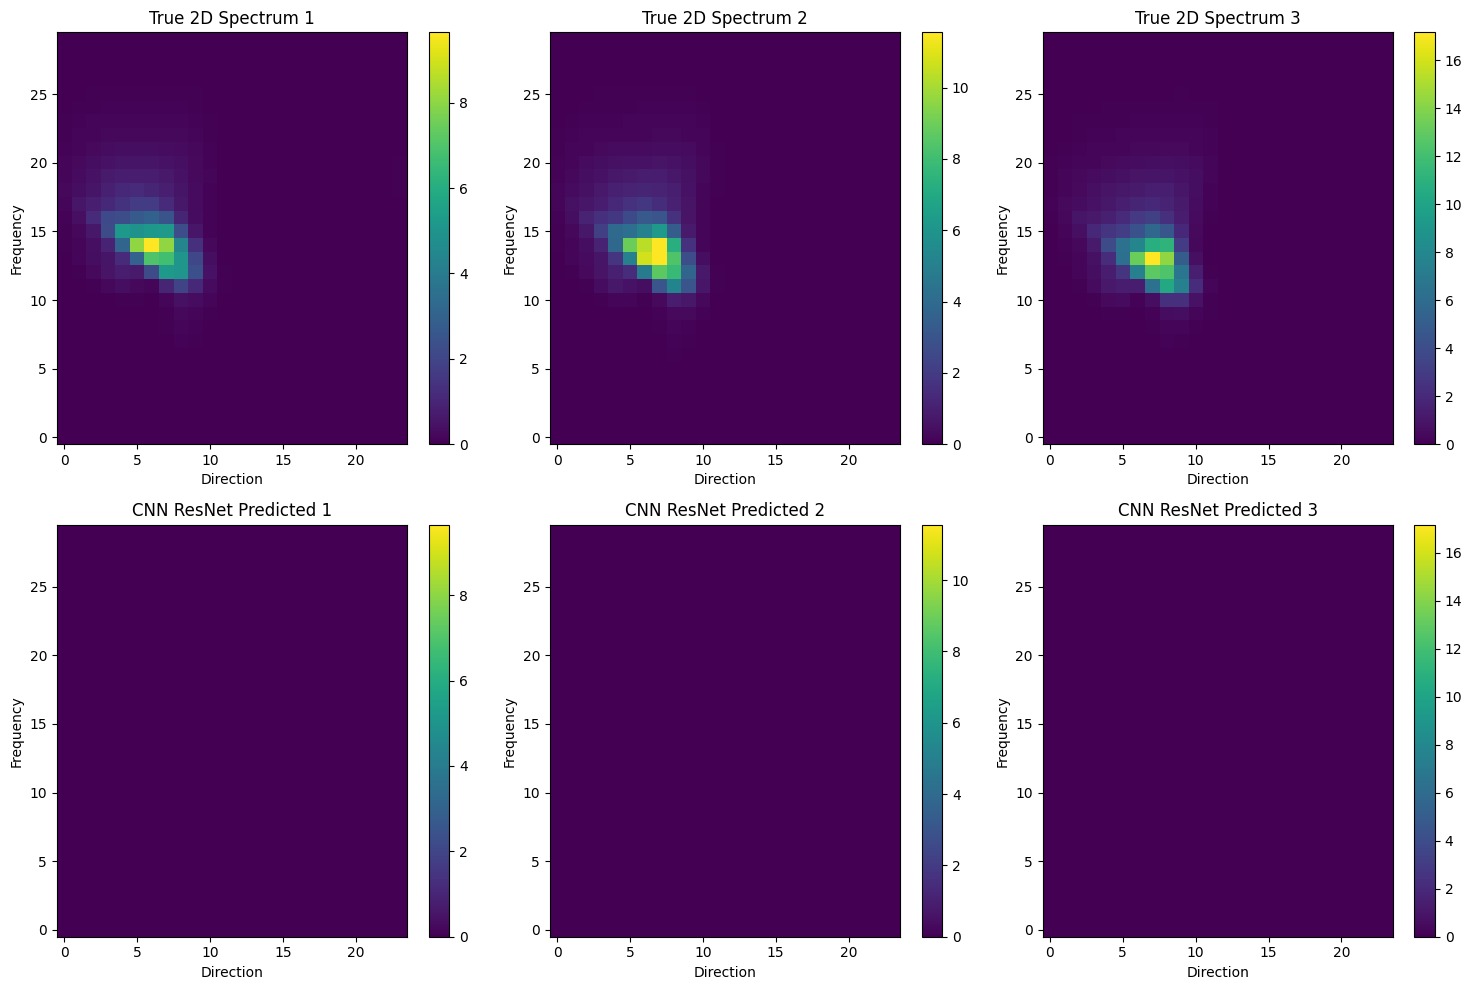

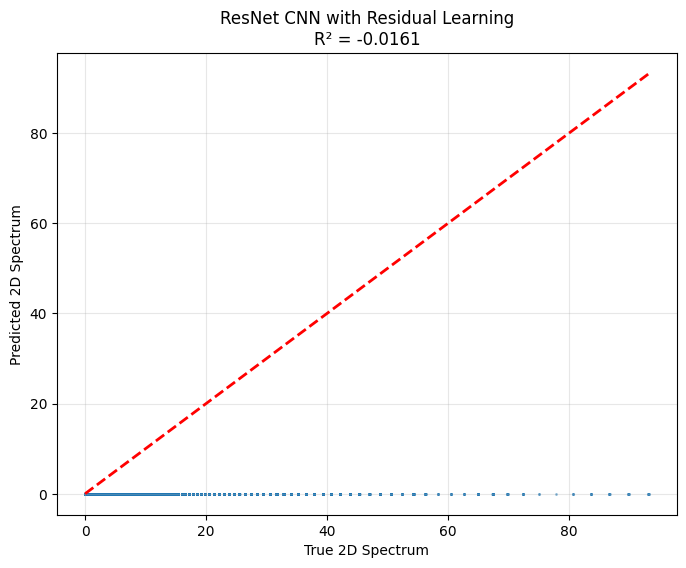

ResNet CNN with residual learning evaluation completed!


In [8]:
# Visualize ERA5 evaluation results  
import matplotlib.pyplot as plt

print("Creating visualization of ResNet CNN with residual learning results...")

# Select 3 representative samples for visualization
sample_indices = [0, 1, 2]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot heatmaps for 3 timestamps
for i, idx in enumerate(sample_indices):
    sample_target = eval_target_np[idx]
    sample_pred = eval_pred_np[idx]
    
    # Determine common color scale for this timestamp
    vmax = max(sample_target.max(), sample_pred.max())
    
    # Top row: True spectra
    im1 = axes[0,i].imshow(sample_target, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[0,i].set_title(f'True 2D Spectrum {idx+1}')
    axes[0,i].set_xlabel('Direction')
    axes[0,i].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[0,i])
    
    # Bottom row: Predicted spectra
    im2 = axes[1,i].imshow(sample_pred, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[1,i].set_title(f'CNN ResNet Predicted {idx+1}')
    axes[1,i].set_xlabel('Direction')
    axes[1,i].set_ylabel('Frequency')
    plt.colorbar(im2, ax=axes[1,i])

plt.tight_layout()
plt.show()

# R² scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(eval_target_np.flatten(), eval_pred_np.flatten(), alpha=0.5, s=1)
plt.plot([eval_target_np.min(), eval_target_np.max()], [eval_target_np.min(), eval_target_np.max()], 'r--', lw=2)
plt.xlabel('True 2D Spectrum')
plt.ylabel('Predicted 2D Spectrum')
plt.title(f'ResNet CNN with Residual Learning\nR² = {eval_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print("="*70)
print("ResNet CNN with residual learning evaluation completed!")
print("="*70)